In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Define the local folder filename
csv_filename = 'ita_wine_reviews.csv'
# Read the CSV file from the specified path
full_path = os.path.join(r'C:\Users\TobyWong\Desktop\School\6211\text_mining\data', csv_filename)
df = pd.read_csv(full_path)
df.head()

,title,description,designation,points,price,province,variety,winery
0,Nicosia 2013 Vulkà Bianco (Etna),"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,White Blend,Nicosia
1,Terre di Giurfo 2013 Belsito Frappato (Vittoria),"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Frappato,Terre di Giurfo
2,Masseria Setteporte 2012 Rosso (Etna),This is dominated by oak and oak-driven aromas...,Rosso,87,NaN,Sicily & Sardinia,Nerello Mascalese,Masseria Setteporte
3,Baglio di Pianetto 2007 Ficiligno White (Sicilia),Delicate aromas recall white flower and citrus...,Ficiligno,87,19.0,Sicily & Sardinia,White Blend,Baglio di Pianetto
4,Canicattì 2009 Aynat Nero d'Avola (Sicilia),"Aromas of prune, blackcurrant, toast and oak c...",Aynat,87,35.0,Sicily & Sardinia,Nero d'Avola,Canicattì


In [5]:
text_series_desc = df['description'].copy()          # For Recall Description
text_series = text_series_desc

def dim(text_series = text_series):
    dimensions = len(set(text_series.str.split().explode().values))
    # same result:
    # dimensions = len(text_series.str.split().explode().unique())
    print(f'{dimensions} dimensions in the potential DFM.')


# Create a function to display top N words and frequency
def top_words(text_series = text_series, n=20):
    freq = text_series.str.split().explode().value_counts()[:n]
    print(f'Top {n} words:\n{freq}')

dim()
top_words()

17941 dimensions in the potential DFM.
Top 20 words:
description
and        48285
of         28217
the        18648
a          18519
with       14614
The        11105
aromas      8951
palate      8436
is          8075
this        7692
wine        6113
offers      5645
This        5637
black       5539
to          5070
that        4795
in          4696
cherry,     4449
on          4133
white       4124
Name: count, dtype: int64


Text Preprocessing

In [ ]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

comments = df["description"].fillna("").astype(str).str.lower()

# Remove stopwords
stop = stopwords.words('english')
comments = comments.apply(lambda x: " ".join(word for word in x.split() if word not in stop))

# Remove punctuation
comments = comments.str.replace(pat=r'[^\w\s]', repl=' ', regex=True)

# Remove digits
comments = comments.str.replace(pat=r'\d+', repl=' ', regex=True)

# Remove extra spaces
comments = comments.str.replace(pat=r'\s+', repl=' ', regex=True).str.strip()

# Lemmatization
lemmatizer = WordNetLemmatizer()
comments = comments.apply(
    lambda x: " ".join(lemmatizer.lemmatize(word) for word in x.split())
)

# Save cleaned text
df["description_clean"] = comments

# Tokenization without NLTK punkt
df["description_tokens"] = df["description_clean"].apply(lambda x: x.split())

print(df[["description", "description_clean", "description_tokens"]].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\TobyWong\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                         description  \
0  Aromas include tropical fruit, broom, brimston...   
1  Here's a bright, informal red that opens with ...   
2  This is dominated by oak and oak-driven aromas...   
3  Delicate aromas recall white flower and citrus...   
4  Aromas of prune, blackcurrant, toast and oak c...   

                                   description_clean  \
0  aroma include tropical fruit broom brimstone d...   
1  here s bright informal red open aroma candied ...   
2  dominated oak oak driven aroma include roasted...   
3  delicate aroma recall white flower citrus pala...   
4  aroma prune blackcurrant toast oak carry extra...   

                                  description_tokens  
0  [aroma, include, tropical, fruit, broom, brims...  
1  [here, s, bright, informal, red, open, aroma, ...  
2  [dominated, oak, oak, driven, aroma, include, ...  
3  [delicate, aroma, recall, white, flower, citru...  
4  [aroma, prune, blackcurrant, toast, oak, carry..

Word Cloud

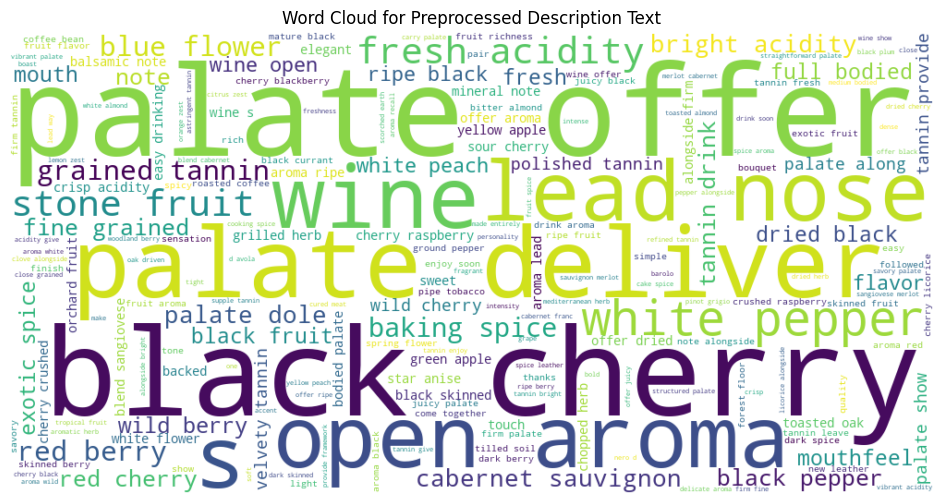

In [ ]:
from wordcloud import WordCloud

# Combine all cleaned text into one string
text_for_wordcloud = " ".join(df["description_clean"].dropna().astype(str))

# Create word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=200
).generate(text_for_wordcloud)

# Plot
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Preprocessed Description Text")
plt.show()

In [10]:
import numpy as np
from collections import Counter, defaultdict
from sklearn.metrics.pairwise import cosine_similarity

tokenized_docs = df["description_clean"].fillna("").apply(lambda x: x.split()).tolist()
tokenized_docs = [doc for doc in tokenized_docs if len(doc) > 0]

all_tokens = [token for doc in tokenized_docs for token in doc]
term_counts = Counter(all_tokens)

# remove very rare words to reduce noise
min_freq = 2
vocab = sorted([term for term, count in term_counts.items() if count >= min_freq])
vocab_index = {term: i for i, term in enumerate(vocab)}

print(f"Vocabulary size (min_freq={min_freq}):", len(vocab))

# build co-occurrence matrix
window_size = 2  # words within +/- 2 positions count as context
cooc_matrix = np.zeros((len(vocab), len(vocab)), dtype=np.float64)

for doc in tokenized_docs:
    for i, term in enumerate(doc):
        if term not in vocab_index:
            continue
        term_i = vocab_index[term]

        start = max(0, i - window_size)
        end = min(len(doc), i + window_size + 1)

        for j in range(start, end):
            if i == j:
                continue
            context_term = doc[j]
            if context_term not in vocab_index:
                continue
            term_j = vocab_index[context_term]
            cooc_matrix[term_i, term_j] += 1

# Similarity function
def top_similar_terms(seed_word, cooc_matrix, vocab, vocab_index, top_n=5):
    if seed_word not in vocab_index:
        return f'"{seed_word}" not found in vocabulary after preprocessing.'

    seed_idx = vocab_index[seed_word]
    seed_vector = cooc_matrix[seed_idx].reshape(1, -1)

    similarities = cosine_similarity(seed_vector, cooc_matrix)[0]

    # Exclude the seed word itself
    similar_terms = []
    for idx, score in enumerate(similarities):
        term = vocab[idx]
        if term != seed_word:
            similar_terms.append((term, score))

    similar_terms = sorted(similar_terms, key=lambda x: x[1], reverse=True)[:top_n]
    return similar_terms

seed_words = ["fruit", "oak", "finish"]

results = {}
for seed in seed_words:
    results[seed] = top_similar_terms(seed, cooc_matrix, vocab, vocab_index, top_n=5)

for seed, sims in results.items():
    print(f"\nTop 5 terms most similar to '{seed}' using Cosine Similarity:")
    if isinstance(sims, str):
        print(sims)
    else:
        for term, score in sims:
            print(f"  {term:<20} similarity = {score:.4f}")

rows = []
for seed, sims in results.items():
    if isinstance(sims, list):
        for rank, (term, score) in enumerate(sims, start=1):
            rows.append([seed, rank, term, score])

results_df = pd.DataFrame(rows, columns=["seed_word", "rank", "similar_term", "cosine_similarity"])
print("\nDetailed results table:")
print(results_df)

Vocabulary size (min_freq=2): 5303

Top 5 terms most similar to 'fruit' using Cosine Similarity:
  plum                 similarity = 0.7074
  mature               similarity = 0.6432
  berry                similarity = 0.6308
  subtle               similarity = 0.6253
  ripe                 similarity = 0.6127

Top 5 terms most similar to 'oak' using Cosine Similarity:
  nut                  similarity = 0.7026
  toast                similarity = 0.6978
  hazelnut             similarity = 0.6879
  espresso             similarity = 0.6465
  vanilla              similarity = 0.6422

Top 5 terms most similar to 'finish' using Cosine Similarity:
  close                similarity = 0.6388
  end                  similarity = 0.6179
  mouth                similarity = 0.5388
  mineral              similarity = 0.5284
  wood                 similarity = 0.5283

Detailed results table:
   seed_word  rank similar_term  cosine_similarity
0      fruit     1         plum           0.707375
1      f

Topic Modeling

In [11]:
import pandas as pd
import nltk
import warnings
warnings.filterwarnings("ignore")

from gensim import corpora
from gensim.models import LdaModel
from pprint import pprint

import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

texts = df["description_clean"].fillna("").apply(lambda x: x.split()).tolist()

# Remove empty documents
texts = [doc for doc in texts if len(doc) > 0]

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.5)  
# no_below=2  -> keep words appearing in at least 2 docs
# no_above=0.5 -> remove words appearing in more than 50% of docs

corpus = [dictionary.doc2bow(text) for text in texts]

num_topics = 3

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    update_every=1,
    chunksize=100,
    passes=10,
    alpha="auto",
    per_word_topics=True
)

print("Top 10 words per topic:\n")
for topic_id, topic_words in lda_model.print_topics(num_topics=num_topics, num_words=10):
    print(f"Topic {topic_id + 1}:")
    print(topic_words)
    print()

vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.display(vis)

Top 10 words per topic:

Topic 1:
0.035*"tannin" + 0.030*"cherry" + 0.028*"black" + 0.018*"drink" + 0.018*"berry" + 0.015*"alongside" + 0.015*"spice" + 0.015*"offer" + 0.015*"red" + 0.014*"note"

Topic 2:
0.039*"wine" + 0.023*"fruit" + 0.018*"s" + 0.014*"spice" + 0.011*"cherry" + 0.010*"show" + 0.010*"bright" + 0.008*"mouth" + 0.008*"note" + 0.008*"tone"

Topic 3:
0.032*"white" + 0.024*"fruit" + 0.023*"acidity" + 0.022*"peach" + 0.020*"apple" + 0.019*"citrus" + 0.018*"note" + 0.017*"offer" + 0.015*"flower" + 0.015*"fresh"

